In [ ]:
import os
import random
import torch
import torchaudio
import soundfile as sf
import numpy as np
from pathlib import Path
from collections import defaultdict
from tqdm import tqdm
from concurrent.futures import ProcessPoolExecutor

# =====================================================
# CONFIG
# =====================================================

DATASET_PATH = "PATH_TO_DATASET"
OUTPUT_PATH = "PATH_TO_OUTPUT"

SAMPLE_RATE = 16000
CLIP_DURATION = 1
CLIP_SAMPLES = SAMPLE_RATE * CLIP_DURATION

TRAIN_RATIO = 0.8
VAL_RATIO = 0.1
TEST_RATIO = 0.1

KEYWORDS = [
    "yes", "no", "up", "down", "left",
    "right", "on", "off", "stop", "go"
]

ALL_CLASSES = KEYWORDS + ["unknown", "silence"]

SILENCE_TRAIN = 1500
SILENCE_VAL = 300
SILENCE_TEST = 300

NUM_WORKERS = 4

# Noise Config
SNR_DB = 5
ADD_NOISE = True

random.seed(42)
torch.manual_seed(42)

# =====================================================
# UTILS
# =====================================================

def extract_speaker_id(filename):
    return filename.split("_nohash_")[0]


def create_dirs():
    for split in ["train", "val", "test"]:
        for cls in ALL_CLASSES:
            os.makedirs(
                os.path.join(OUTPUT_PATH, split, cls),
                exist_ok=True
            )


def group_by_speaker():
    speaker_dict = defaultdict(list)

    for folder in os.listdir(DATASET_PATH):
        path = os.path.join(DATASET_PATH, folder)

        if not os.path.isdir(path):
            continue

        if folder == "_background_noise_":
            continue

        for file in os.listdir(path):
            if file.endswith(".wav"):
                speaker_id = extract_speaker_id(file)
                speaker_dict[speaker_id].append(
                    os.path.join(path, file)
                )

    return speaker_dict


def split_speakers(speaker_dict):
    speakers = list(speaker_dict.keys())
    random.shuffle(speakers)

    total = len(speakers)

    train_end = int(total * TRAIN_RATIO)
    val_end = train_end + int(total * VAL_RATIO)

    train = speakers[:train_end]
    val = speakers[train_end:val_end]
    test = speakers[val_end:]

    return train, val, test

# =====================================================
# PRELOAD NOISE
# =====================================================

def preload_noise():
    noise_folder = os.path.join(DATASET_PATH, "_background_noise_")
    noise_bank = []

    for file in os.listdir(noise_folder):
        if file.endswith(".wav"):
            wave, sr = torchaudio.load(
                os.path.join(noise_folder, file)
            )

            if sr != SAMPLE_RATE:
                wave = torchaudio.functional.resample(
                    wave, sr, SAMPLE_RATE
                )

            noise_bank.append(wave.numpy())

    print(f"Loaded {len(noise_bank)} noise files")
    return noise_bank


NOISE_BANK = preload_noise()

# =====================================================
# AUDIO HELPERS
# =====================================================

def fix_length(wave):
    if wave.shape[1] > CLIP_SAMPLES:
        return wave[:, :CLIP_SAMPLES]

    elif wave.shape[1] < CLIP_SAMPLES:
        pad = CLIP_SAMPLES - wave.shape[1]
        return torch.nn.functional.pad(wave, (0, pad))

    return wave


def add_noise_snr(signal, noise, snr_db):
    signal = signal.numpy()
    noise = noise.astype(np.float32)

    # match length
    if noise.shape[1] > signal.shape[1]:
        start = random.randint(0, noise.shape[1] - signal.shape[1])
        noise = noise[:, start:start + signal.shape[1]]
    else:
        pad = signal.shape[1] - noise.shape[1]
        noise = np.pad(noise, ((0, 0), (0, pad)))

    # compute power
    signal_power = np.mean(signal ** 2)
    noise_power = np.mean(noise ** 2) + 1e-10

    # scale noise for target SNR
    scale = np.sqrt(signal_power / (noise_power * (10 ** (snr_db / 10))))
    noise = noise * scale

    mixed = signal + noise
    return torch.tensor(mixed, dtype=torch.float32)

# =====================================================
# FILE PROCESSING
# =====================================================

def process_file(task):
    file_path, split_name = task

    label = Path(file_path).parent.name

    if label not in KEYWORDS:
        label = "unknown"

    wave, sr = torchaudio.load(file_path)

    if sr != SAMPLE_RATE:
        wave = torchaudio.functional.resample(
            wave, sr, SAMPLE_RATE
        )

    wave = fix_length(wave)

    # -------------------------
    # SAVE CLEAN
    # -------------------------
    clean_path = os.path.join(
        OUTPUT_PATH,
        split_name,
        label,
        os.path.basename(file_path)
    )

    sf.write(clean_path, wave.squeeze().numpy(), SAMPLE_RATE)

    # -------------------------
    # SAVE NOISY (5 dB)
    # -------------------------
    if ADD_NOISE and label != "silence":

        noise = random.choice(NOISE_BANK)

        noisy_wave = add_noise_snr(wave, noise, SNR_DB)

        noisy_name = os.path.basename(file_path).replace(".wav", "_noise.wav")

        noisy_path = os.path.join(
            OUTPUT_PATH,
            split_name,
            label,
            noisy_name
        )

        sf.write(noisy_path, noisy_wave.squeeze().numpy(), SAMPLE_RATE)

# =====================================================
# PARALLEL PROCESSING
# =====================================================

def process_split_parallel(speaker_list, split_name, speaker_dict):

    tasks = []

    for spk in speaker_list:
        for file in speaker_dict[spk]:
            tasks.append((file, split_name))

    with ProcessPoolExecutor(max_workers=NUM_WORKERS) as executor:
        list(
            tqdm(
                executor.map(process_file, tasks),
                total=len(tasks),
                desc=f"{split_name}"
            )
        )

# =====================================================
# SILENCE GENERATION
# =====================================================

def generate_silence(split_name, count):

    silence_dir = os.path.join(
        OUTPUT_PATH,
        split_name,
        "silence"
    )

    for i in tqdm(range(count), desc=f"silence {split_name}"):

        noise = random.choice(NOISE_BANK)

        if noise.shape[1] > CLIP_SAMPLES:
            start = random.randint(
                0,
                noise.shape[1] - CLIP_SAMPLES
            )

            chunk = noise[:, start:start + CLIP_SAMPLES]

        else:
            pad = CLIP_SAMPLES - noise.shape[1]
            chunk = np.pad(noise, ((0, 0), (0, pad)))

        chunk = chunk * random.uniform(0.05, 0.2)

        sf.write(
            os.path.join(
                silence_dir,
                f"silence_{split_name}_{i}.wav"
            ),
            chunk.squeeze(),
            SAMPLE_RATE
        )

# =====================================================
# COUNT DATASET
# =====================================================

def count_dataset():

    total_all = 0

    for split in ["train", "val", "test"]:

        print(f"\n===== {split.upper()} =====")

        split_total = 0
        split_path = os.path.join(OUTPUT_PATH, split)

        for cls in sorted(os.listdir(split_path)):

            cls_path = os.path.join(split_path, cls)

            if not os.path.isdir(cls_path):
                continue

            count = len([
                f for f in os.listdir(cls_path)
                if f.endswith(".wav")
            ])

            print(f"{cls:10s}: {count}")

            split_total += count

        print(f"TOTAL {split}: {split_total}")

        total_all += split_total

    print("\n====================")
    print(f"GRAND TOTAL: {total_all}")

# =====================================================
# MAIN
# =====================================================

def main():

    create_dirs()

    speaker_dict = group_by_speaker()

    train_spk, val_spk, test_spk = split_speakers(speaker_dict)

    print("\nProcessing TRAIN")
    process_split_parallel(train_spk, "train", speaker_dict)
    generate_silence("train", SILENCE_TRAIN)

    print("\nProcessing VAL")
    process_split_parallel(val_spk, "val", speaker_dict)
    generate_silence("val", SILENCE_VAL)

    print("\nProcessing TEST")
    process_split_parallel(test_spk, "test", speaker_dict)
    generate_silence("test", SILENCE_TEST)

    print("\nDONE ")

    count_dataset()


if __name__ == "__main__":
    main()

Loaded 5 noise files

Processing TRAIN


silence train: 100%|██████████| 1500/1500 [00:08<00:00, 168.07it/s]


Processing VAL



silence val: 100%|██████████| 300/300 [00:01<00:00, 176.95it/s]


Processing TEST



silence test: 100%|██████████| 300/300 [00:01<00:00, 190.61it/s]



DONE ✅

===== TRAIN =====
down      : 6764
go        : 6272
left      : 6082
no        : 6982
off       : 5984
on        : 6130
right     : 6066
silence   : 1500
stop      : 6198
unknown   : 13210
up        : 6678
yes       : 7214
TOTAL train: 79080

===== VAL =====
down      : 856
go        : 750
left      : 742
no        : 914
off       : 752
on        : 774
right     : 732
silence   : 300
stop      : 772
unknown   : 1700
up        : 910
yes       : 998
TOTAL val: 10200

===== TEST =====
down      : 910
go        : 738
left      : 778
no        : 968
off       : 754
on        : 786
right     : 758
silence   : 300
stop      : 774
unknown   : 1648
up        : 860
yes       : 962
TOTAL test: 10236

GRAND TOTAL: 99516


In [ ]:
import os
import torch
import torchaudio
import numpy as np
from tqdm import tqdm

# -----------------------
# CONFIG
# -----------------------
SAMPLE_RATE = 16000
N_MFCC = 40
N_FFT = 400
HOP_LENGTH = 160
FIXED_LENGTH = 16000   # 1 second

# -----------------------
# MFCC Transform
# -----------------------
mfcc_transform = torchaudio.transforms.MFCC(
    sample_rate=SAMPLE_RATE,
    n_mfcc=N_MFCC,
    melkwargs={
        'n_fft': N_FFT,
        'hop_length': HOP_LENGTH,
        'n_mels': 40
    }
)

# -----------------------
# Pad / Trim
# -----------------------
def pad_trim(waveform):
    if waveform.shape[1] < FIXED_LENGTH:
        pad = FIXED_LENGTH - waveform.shape[1]
        waveform = torch.nn.functional.pad(waveform, (0, pad))
    else:
        waveform = waveform[:, :FIXED_LENGTH]
    return waveform

# -----------------------
# Process folder
# -----------------------
def process_folder(root_dir):
    X = []
    y = []
    labels = sorted([
                  d for d in os.listdir(root_dir)
                  if os.path.isdir(os.path.join(root_dir, d))
              ])
    label_map = {label:i for i,label in enumerate(labels)}

    for label in labels:
        label_path = os.path.join(root_dir, label)

        if not os.path.isdir(label_path):
            continue

        for file in tqdm(os.listdir(label_path), desc=label):
            if file.endswith(".wav"):
                path = os.path.join(label_path, file)

                waveform, sr = torchaudio.load(path)

                if sr != SAMPLE_RATE:
                    waveform = torchaudio.functional.resample(waveform, sr, SAMPLE_RATE)

                waveform = pad_trim(waveform)

                mfcc = mfcc_transform(waveform)
                mfcc = mfcc.squeeze(0)

                X.append(mfcc)
                y.append(label_map[label])

    return torch.stack(X), torch.tensor(y)

# -----------------------
# Paths
# -----------------------
train_dir = "/content/speech_commands_split/train"
val_dir   = "/content/speech_commands_split/val"
test_dir  = "/content/speech_commands_split/test"

# -----------------------
# Extract
# -----------------------
X_train, y_train = process_folder(train_dir)
X_val, y_val = process_folder(val_dir)
X_test, y_test = process_folder(test_dir)

# -----------------------
# Save
# -----------------------
torch.save({
    "X_train": X_train,
    "y_train": y_train,
    "X_val": X_val,
    "y_val": y_val,
    "X_test": X_test,
    "y_test": y_test
}, "gsc_mfcc_40x98.pt")

print(X_train.shape)

yes: 100%|██████████| 962/962 [00:05<00:00, 184.20it/s]


torch.Size([79080, 40, 101])


Train shape: torch.Size([79080, 40, 101])
Train labels: torch.Size([79080])
Val shape: torch.Size([10200, 40, 101])
Val labels: torch.Size([10200])
Test shape: torch.Size([10236, 40, 101])
Test labels: torch.Size([10236])
Train min: -632.455810546875
Train max: 198.22291564941406
Train mean: -2.496880531311035
Train std: 26.023555755615234
Unique labels: tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])
Num classes: 12
Single sample shape: torch.Size([40, 101])


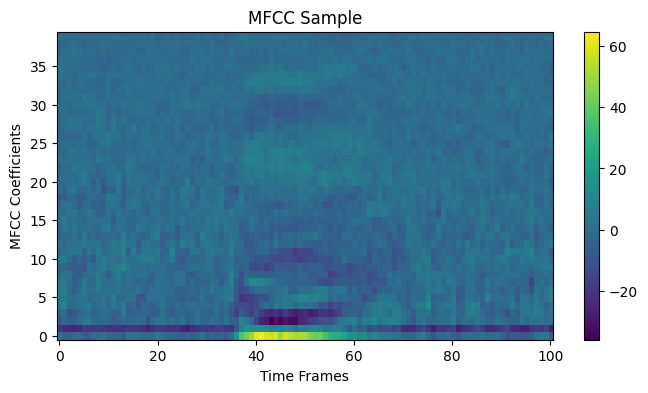

In [ ]:
import torch
import matplotlib.pyplot as plt

# Load file
data = torch.load("gsc_mfcc_40x98.pt")

# Extract tensors
X_train = data["X_train"]
y_train = data["y_train"]

X_val = data["X_val"]
y_val = data["y_val"]

X_test = data["X_test"]
y_test = data["y_test"]

# -------------------------
# Basic shape check
# -------------------------
print("Train shape:", X_train.shape)
print("Train labels:", y_train.shape)

print("Val shape:", X_val.shape)
print("Val labels:", y_val.shape)

print("Test shape:", X_test.shape)
print("Test labels:", y_test.shape)

# -------------------------
# Value range
# -------------------------
print("Train min:", X_train.min().item())
print("Train max:", X_train.max().item())
print("Train mean:", X_train.mean().item())
print("Train std:", X_train.std().item())

# -------------------------
# Label check
# -------------------------
print("Unique labels:", torch.unique(y_train))
print("Num classes:", len(torch.unique(y_train)))

# -------------------------
# One sample inspect
# -------------------------
sample = X_train[0]

print("Single sample shape:", sample.shape)

# -------------------------
# Visualize MFCC
# -------------------------
plt.figure(figsize=(8,4))
plt.imshow(sample.numpy(), aspect='auto', origin='lower')
plt.title("MFCC Sample")
plt.xlabel("Time Frames")
plt.ylabel("MFCC Coefficients")
plt.colorbar()
plt.show()

In [ ]:
!cp /content/gsc_mfcc_40x98.pt /content/drive/MyDrive/KWS

In [ ]:
!zip -r /content/speech_commands_split.zip /content/speech_commands_split
